# Lab05 - Pandas

Stanisław Nieradko 193044

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from timeit import default_timer as timer

file_path = 'datasets/5.csv'
df = pd.read_csv(file_path, low_memory=False)

print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (3300757, 41)


,Unique Key,Created Date,Closed Date,Agency,Agency Name,Complaint Type,Descriptor,Location Type,Incident Zip,Incident Address,...,Vehicle Type,Taxi Company Borough,Taxi Pick Up Location,Bridge Highway Name,Bridge Highway Direction,Road Ramp,Bridge Highway Segment,Latitude,Longitude,Location
0,43355447,07/23/2019 09:53:00 AM,07/27/2019 12:00:00 AM,DSNY,Department of Sanitation,Request Large Bulky Item Collection,Request Large Bulky Item Collection,Sidewalk,11434,170-36 118 AVENUE,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.685812,-73.775582,"(40.68581214768514, -73.77558194061874)"
1,43352471,07/22/2019 04:03:00 PM,08/05/2019 11:20:00 AM,DEP,Department of Environmental Protection,Water System,Hydrant Defective (WC2),NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,43348925,07/22/2019 01:31:00 PM,NaN,DSNY,Department of Sanitation,Literature Request,BULK FLYER/SPECIAL WASTE,Other,10466,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,30098557,03/04/2015 03:39:00 AM,03/04/2015 11:50:00 AM,DOT,Department of Transportation,Traffic Signal Condition,Controller,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,43362962,07/23/2019 10:45:00 AM,07/25/2019 12:00:00 PM,DSNY,Department of Sanitation,Sanitation Condition,15 Street Cond/Dump-Out/Drop-Off,Street,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 1. 10 najczęściej zgłaszanych skarg ('Complaint Type')

In [2]:
start = timer()
top_10_complaints = df['Complaint Type'].value_counts().head(10)
end = timer()

print(f"Czas wykonania: {end - start:.4f}s")
print("\n10 najczęściej zgłaszanych skarg:")
print(top_10_complaints)

Czas wykonania: 0.1105s

10 najczęściej zgłaszanych skarg:
Complaint Type
HEATING                   320518
GENERAL CONSTRUCTION      200602
Street Condition          182042
Street Light Condition    181450
Noise - Residential       180990
PLUMBING                  172803
PAINT - PLASTER           146160
Water System              113672
NONCONST                  108192
Literature Request         90880
Name: count, dtype: int64


## 2. 3 najczęściej zgłaszane skargi ('Complaint Type') w każdej dzielnicy ('Borough')

In [3]:
start = timer()
boroughs = df['Borough'].unique()
print(f"Boroughs: {list(boroughs)}\n")

for borough in boroughs:
    if pd.isna(borough) or borough == 'Unspecified':
        continue
    print(f"Borough: {borough}")
    borough_data = df[df['Borough'] == borough]
    top_3_in_borough = borough_data['Complaint Type'].value_counts().head(3)
    print(top_3_in_borough)
    print("-" * 30)

end = timer()
print(f"\nCzas wykonania: {end - start:.4f}s")

Boroughs: ['QUEENS', 'BRONX', 'BROOKLYN', 'Unspecified', 'MANHATTAN', nan, 'STATEN ISLAND']

Borough: QUEENS
Complaint Type
Street Light Condition    57890
Street Condition          50423
Noise - Residential       34522
Name: count, dtype: int64
------------------------------
Borough: BRONX
Complaint Type
Noise - Residential       48304
Street Light Condition    36789
Water System              23176
Name: count, dtype: int64
------------------------------
Borough: BROOKLYN
Complaint Type
Noise - Residential       54048
Street Condition          50829
Street Light Condition    48975
Name: count, dtype: int64
------------------------------
Borough: MANHATTAN
Complaint Type
Noise - Residential    39259
Street Condition       37277
Taxi Complaint         23677
Name: count, dtype: int64
------------------------------
Borough: STATEN ISLAND
Complaint Type
Street Condition          22640
Street Light Condition    10906
Literature Request        10895
Name: count, dtype: int64
----------------

## 3. 3 urzędy ('Agency Name'), do których najczęściej zgłaszano skargi (z wymieniem 3 najpopularniejszych skarg dla każdego urzędu)

In [4]:
start = timer()
top_3_agencies = df['Agency Name'].value_counts().head(3)

for agency in top_3_agencies.index:
    print(f"Agency: {agency}")
    agency_data = df[df['Agency Name'] == agency]
    top_3_complaints = agency_data['Complaint Type'].value_counts().head(3)
    print(top_3_complaints)
    print("-" * 30)

end = timer()
print(f"\nCzas wykonania: {end - start:.4f}s")

Agency: Department of Housing Preservation and Development
Complaint Type
HEATING                 320518
GENERAL CONSTRUCTION    200602
PLUMBING                172803
Name: count, dtype: int64
------------------------------
Agency: Department of Transportation
Complaint Type
Street Condition            182041
Street Light Condition      181450
Traffic Signal Condition     85210
Name: count, dtype: int64
------------------------------
Agency: New York City Police Department
Complaint Type
Noise - Residential    180941
Blocked Driveway        81871
Illegal Parking         41803
Name: count, dtype: int64
------------------------------

Czas wykonania: 0.7517s


## 4. 4 lokalizacje ('Location Type'), w których najczęściej zgłaszano skargi (z wymieniem 2 najpopularniejszych skarg dla każdej lokalizacji)

In [5]:
start = timer()
top_4_locations = df['Location Type'].value_counts().head(4)

for location in top_4_locations.index:
    print(f"Location: {location}")
    location_data = df[df['Location Type'] == location]
    top_2_complaints = location_data['Complaint Type'].value_counts().head(2)
    print(top_2_complaints)
    print("-" * 30)

end = timer()
print(f"\nCzas wykonania: {end - start:.4f}s")

Location: RESIDENTIAL BUILDING
Complaint Type
HEATING                 320518
GENERAL CONSTRUCTION    200602
Name: count, dtype: int64
------------------------------
Location: Street
Complaint Type
Street Condition    75598
Damaged Tree        47538
Name: count, dtype: int64
------------------------------
Location: Street/Sidewalk
Complaint Type
Blocked Driveway    81871
Illegal Parking     41802
Name: count, dtype: int64
------------------------------
Location: Residential Building/House
Complaint Type
Noise - Residential            180990
Non-Emergency Police Matter      2249
Name: count, dtype: int64
------------------------------

Czas wykonania: 0.7633s


## 5. Procentowy udział zgłoszeń o różnych statusach realizacji ('Status'): 'in Progress', 'Closed', 'Open', 'Assigned'. Przedstaw dane w postaci wykresu kołowego.

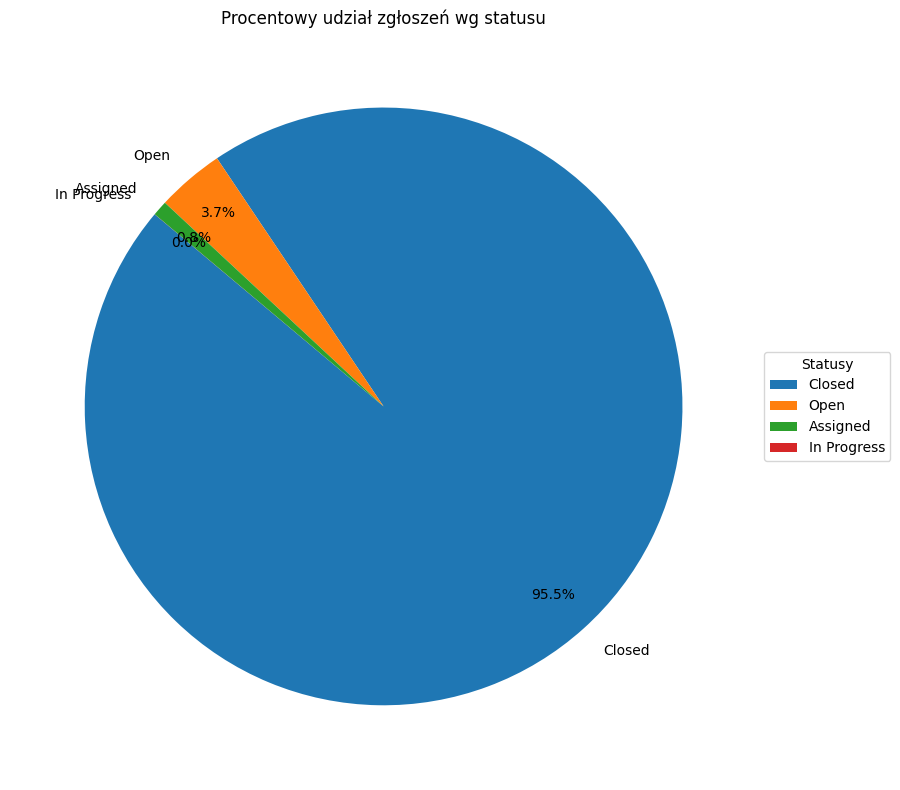

Czas wykonania: 0.5697s


In [ ]:
start = timer()
target_statuses = ['In Progress', 'Closed', 'Open', 'Assigned']
filtered_df = df[df['Status'].isin(target_statuses)]
status_counts = filtered_df['Status'].value_counts()

plt.figure(figsize=(12, 8))
plt.pie(status_counts, labels=status_counts.index, autopct='%1.1f%%', startangle=140, pctdistance=0.85)
plt.legend(status_counts.index, title="Statusy", loc="center left", bbox_to_anchor=(1, 0, 0.5, 1))
plt.title('Procentowy udział zgłoszeń wg statusu')
plt.tight_layout()
plt.show()

end = timer()
print(f"Czas wykonania: {end - start:.4f}s")